## Quantitative Developer Assignment

## Part 1 — Data Extraction
Objective

Download historical stock data from Yahoo Finance for three equities.

Selected stocks:

    AAPL — Apple

    MSFT — Microsoft

    GOOGL — Alphabet

These are large-cap equities with high liquidity and reliable historical data.

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

In [3]:
tickers = ["AAPL", "MSFT", "GOOGL"]

end = datetime.today()
start = end - timedelta(days=3*365)

In [4]:
data = yf.download(
    tickers,
    start=start,
    end=end,
    auto_adjust=False,
    progress=False
)

data.head()

Price        Adj Close                               Close              \
Ticker            AAPL       GOOGL        MSFT        AAPL       GOOGL   
Date                                                                     
2023-03-13  148.321243   90.363152  248.045792  150.470001   91.110001   
2023-03-14  150.410980   93.199699  254.756866  152.589996   93.970001   
2023-03-15  150.805283   95.322151  259.299316  152.990005   96.110001   
2023-03-16  153.624451   99.497650  269.810394  155.850006  100.320000   
2023-03-17  152.786560  100.786995  272.965668  155.000000  101.620003   

Price                         High                                 Low  \
Ticker            MSFT        AAPL       GOOGL        MSFT        AAPL   
Date                                                                     
2023-03-13  253.919998  153.139999   92.570000  257.910004  147.699997   
2023-03-14  260.790009  153.399994   94.360001  261.070007  150.100006   
2023-03-15  265.440002  153.250000   96.930000  266.480011  149.919998   
2023-03-16  276.200012  156.460007  101.190002  276.559998  151.639999   
2023-03-17  279.429993  156.740005  102.839996  283.329987  154.279999   

Price                                     Open                          \
Ticker           GOOGL        MSFT        AAPL       GOOGL        MSFT   
Date                                                                     
2023-03-13   89.419998  245.729996  147.809998   90.089996  247.399994   
2023-03-14   92.440002  255.860001  151.279999   92.559998  256.750000   
2023-03-15   92.639999  259.209991  151.190002   93.220001  259.980011   
2023-03-16   95.500000  263.279999  152.160004   96.199997  265.209991   
2023-03-17  100.099998  276.320007  156.080002  100.260002  278.260010   

Price         Volume                      
Ticker          AAPL     GOOGL      MSFT  
Date                                      
2023-03-13  84457100  37335600  33339700  
2023-03-14  73695900  36050200  33620300  
2023-03-15  77167900  50622100  46028000  
2023-03-16  76161100  65492000  54768800  
2023-03-17  98944600  61028500  69527400

In [36]:
data.to_csv("data/stock_data_raw.csv")

## Part 2 — Data Cleaning and Preprocessing

Financial time series often contain and before analysis should be processed:

    missing values

    duplicate timestamps

    misaligned trading dates


In [6]:
cleaned = {}

for ticker in tickers:

    df = data.xs(ticker, level=1, axis=1).copy()

    df.index = pd.to_datetime(df.index)

    df = df[~df.index.duplicated()]

    df = df.dropna()

    cleaned[ticker] = df

In [7]:
common_dates = cleaned[tickers[0]].index

for ticker in tickers[1:]:
    common_dates = common_dates.intersection(cleaned[ticker].index)

for ticker in tickers:
    cleaned[ticker] = cleaned[ticker].loc[common_dates]

## Part 3 — Feature Engineering

We compute financial indicators used in quantitative analysis.

Features:

    daily returns

    log returns

    moving averages

    rolling volatility

In [8]:
TRADING_DAYS = 252

for ticker, df in cleaned.items():

    df["daily_return"] = df["Close"].pct_change()

    df["log_return"] = np.log(df["Close"] / df["Close"].shift(1))

    df["MA20"] = df["Close"].rolling(20).mean()

    df["MA50"] = df["Close"].rolling(50).mean()

    df["volatility_30"] = df["daily_return"].rolling(30).std()

    cleaned[ticker] = df.dropna()

## Part 4 — Basic Analytics

Compute risk metrics for each stock.

Metrics:

    mean return

    standard deviation

    annualized volatility

In [25]:
# ------------------------------------------------
# BASIC ANALYTICS
# ------------------------------------------------

TRADING_DAYS = 252   # Approximate number of trading days in a year

returns_df = pd.DataFrame()

for ticker, df in cleaned.items():

    # Extract daily returns and remove NaN values created by pct_change
    r = df["daily_return"].dropna()

    # Mean daily return
    mean_daily = r.mean()

    # Standard deviation of daily returns
    std_daily = r.std()

    # Annualized volatility
    # Important: volatility scales with sqrt(time)
    annual_vol = std_daily * np.sqrt(TRADING_DAYS)

    print("Ticker:", ticker)
    print("Mean Daily Return:", mean_daily)
    print("Standard Deviation:", std_daily)
    print("Annualized Volatility:", annual_vol)
    print()

    # Store returns for correlation analysis
    returns_df[ticker] = r

Ticker: AAPL
Mean Daily Return: 0.0006992496152555791
Standard Deviation: 0.016370636001456166
Annualized Volatility: 0.259875789982883

Ticker: MSFT
Mean Daily Return: 0.0004495976113399852
Standard Deviation: 0.01465510076009705
Annualized Volatility: 0.2326425122988627

Ticker: GOOGL
Mean Daily Return: 0.0014790942871858006
Standard Deviation: 0.01827790120209298
Annualized Volatility: 0.29015268641367936



## Part 5 — Visualization
Price History

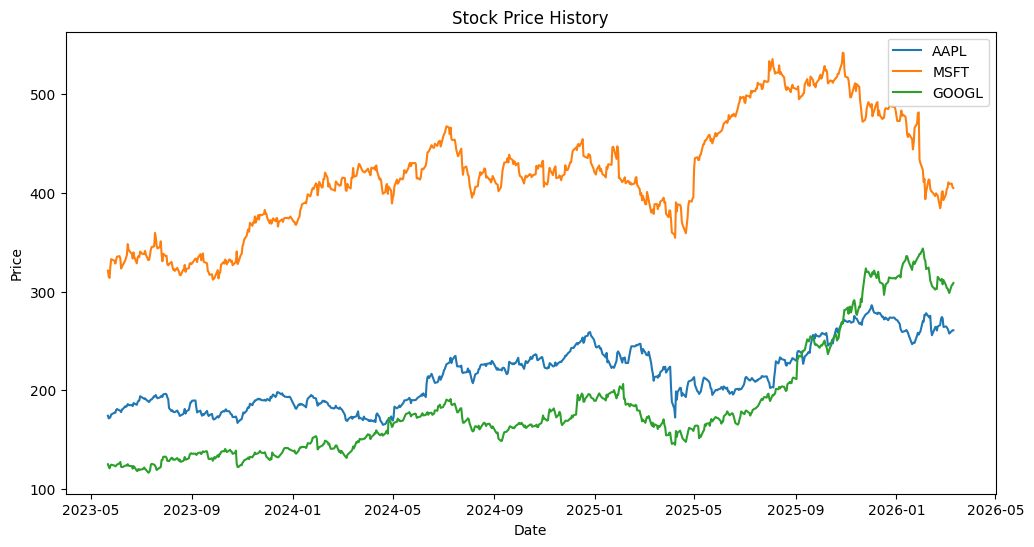

In [26]:
# ------------------------------------------------
# PRICE HISTORY
# ------------------------------------------------

plt.figure(figsize=(12,6))

for ticker, df in cleaned.items():

    # Plot closing price of each asset
    plt.plot(df.index, df["Close"], label=ticker)

plt.title("Stock Price History")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()

plt.show()

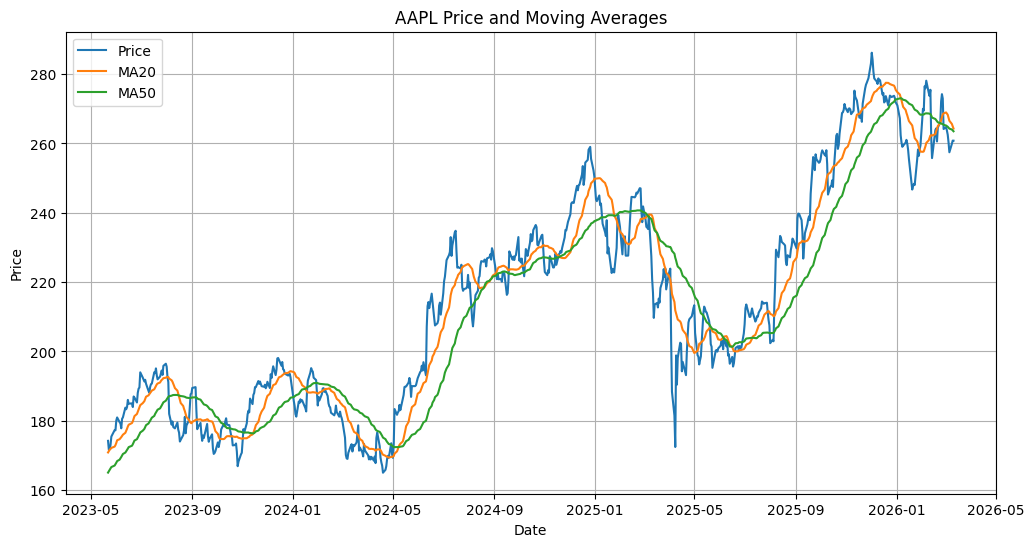

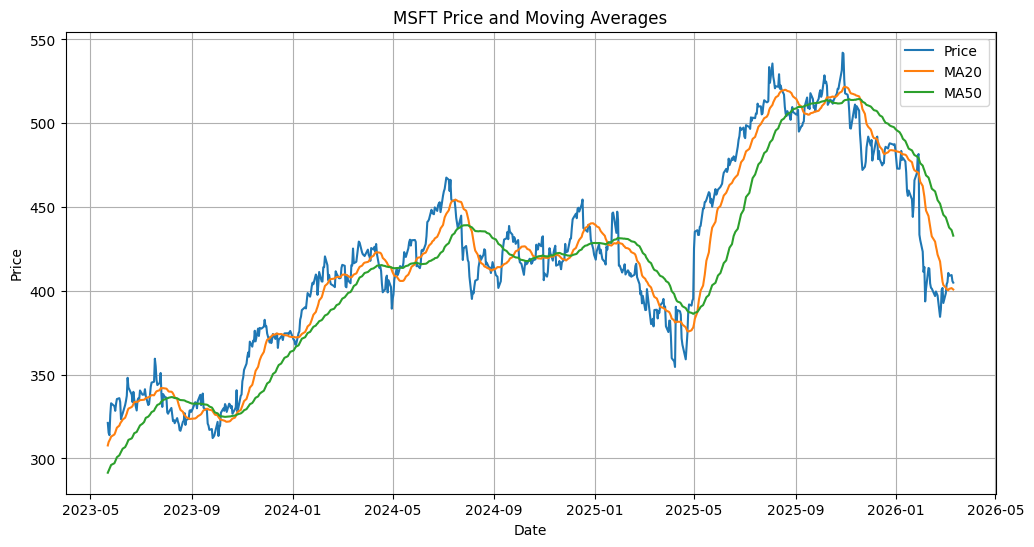

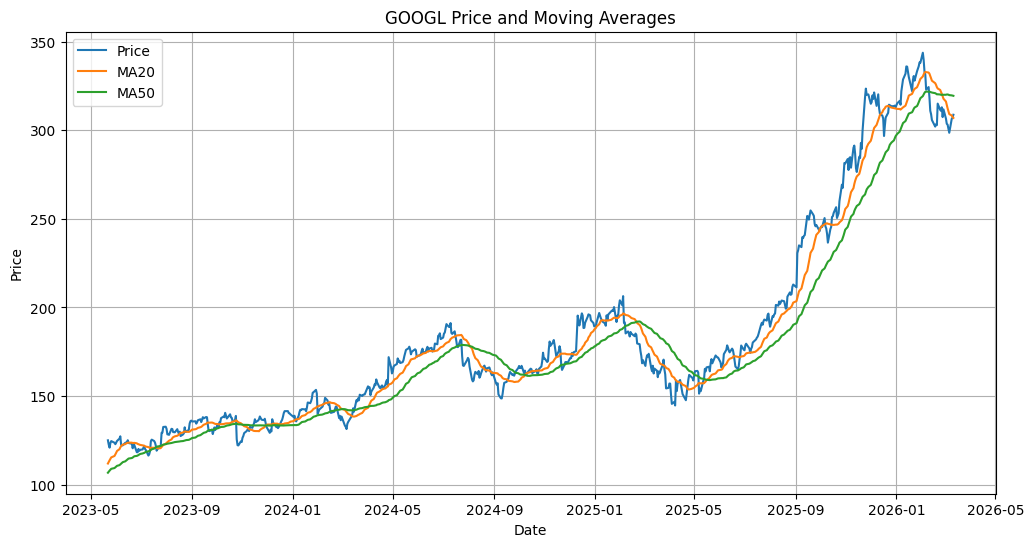

In [31]:
# ------------------------------------------------
# MOVING AVERAGES
# ------------------------------------------------

for ticker in tickers:

    df = cleaned[ticker]

    plt.figure(figsize=(12,6))   # new chart for each stock

    # Plot closing price
    plt.plot(df.index, df["Close"], label="Price")

    # Plot moving averages
    plt.plot(df.index, df["MA20"], label="MA20")
    plt.plot(df.index, df["MA50"], label="MA50")

    plt.title(f"{ticker} Price and Moving Averages")
    plt.xlabel("Date")
    plt.ylabel("Price")

    plt.legend()
    plt.grid(True)

    plt.show()

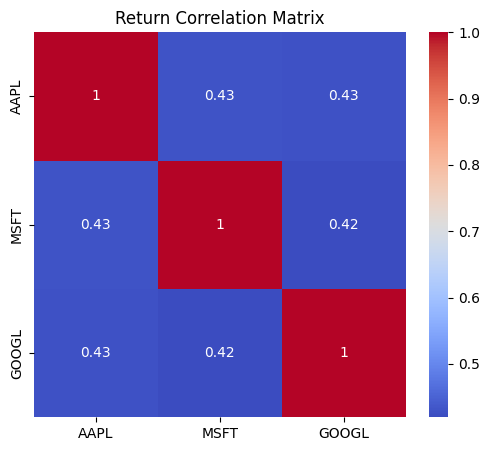

In [28]:
plt.figure(figsize=(6,5))

sns.heatmap(returns_df.corr(), annot=True, cmap="coolwarm")

plt.title("Return Correlation Matrix")

plt.show()

## Part 6 — Strategy Evaluation (Bonus)

Buy when:

    MA20 > MA50

Sell when:

MA20 < MA50

Strategy Total Return: 0.23167055581261886
Buy & Hold Return: 0.48898145755755107
Strategy Volatility: 0.16875617264124987
Strategy Sharpe Ratio: 0.527431770309404
Number of Trades: 16


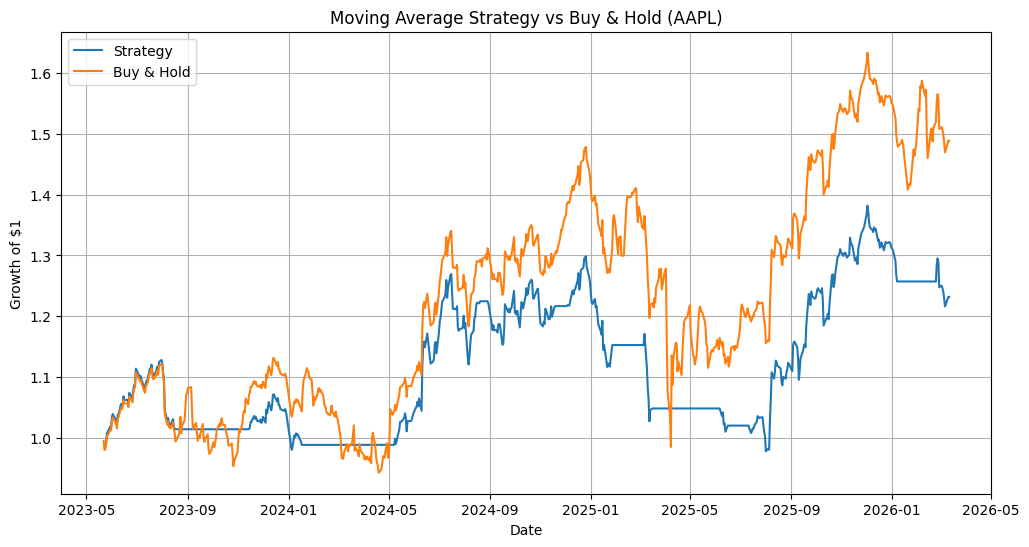

In [34]:
# ------------------------------------------------
# MOVING AVERAGE CROSSOVER STRATEGY (FIXED)
# ------------------------------------------------

TRADING_DAYS = 252

df = cleaned["AAPL"].copy()

# ------------------------------------------------
# POSITION LOGIC
# ------------------------------------------------
# Stay invested whenever MA20 > MA50
# This avoids the earlier signal bug where the strategy stayed flat

df["position"] = np.where(df["MA20"] > df["MA50"], 1, 0)

# ------------------------------------------------
# STRATEGY RETURNS
# ------------------------------------------------
# Shift position to avoid look-ahead bias
df["strategy_return"] = df["position"].shift(1) * df["daily_return"]

# ------------------------------------------------
# CUMULATIVE RETURNS
# ------------------------------------------------
df["cum_strategy"] = (1 + df["strategy_return"]).cumprod()
df["cum_buy_hold"] = (1 + df["daily_return"]).cumprod()

# ------------------------------------------------
# PERFORMANCE METRICS
# ------------------------------------------------
r = df["strategy_return"].dropna()

strategy_return = df["cum_strategy"].iloc[-1] - 1
buy_hold_return = df["cum_buy_hold"].iloc[-1] - 1

volatility = r.std() * np.sqrt(TRADING_DAYS)
sharpe = (r.mean() / r.std()) * np.sqrt(TRADING_DAYS)

print("Strategy Total Return:", strategy_return)
print("Buy & Hold Return:", buy_hold_return)
print("Strategy Volatility:", volatility)
print("Strategy Sharpe Ratio:", sharpe)

# ------------------------------------------------
# DEBUG: NUMBER OF TRADES
# ------------------------------------------------
trades = df["position"].diff().abs().sum()
print("Number of Trades:", int(trades))

# ------------------------------------------------
# EQUITY CURVE
# ------------------------------------------------
plt.figure(figsize=(12,6))

plt.plot(df.index, df["cum_strategy"], label="Strategy")
plt.plot(df.index, df["cum_buy_hold"], label="Buy & Hold")

plt.title("Moving Average Strategy vs Buy & Hold (AAPL)")
plt.xlabel("Date")
plt.ylabel("Growth of $1")

plt.legend()
plt.grid(True)

plt.show()